In [1]:
#install.packages(c("dplyr", "ggplot2", "readr", "stringr", "tidyr", "splines", "purrr"))

library(dplyr)
library(ggplot2)
library(readr)
library(stringr)
library(tidyr)
library(splines)
library(purrr)


Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union




In [2]:
# -------------------------------------------------------------------
# 1) Carregar o CSV
# -------------------------------------------------------------------
dados <- read_csv("phase3/output/2025-11-20_17-48-37/benchmark_results_2025-11-20_20-48-41_fixed.csv")

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 300 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): algorithm, filename
dbl (20): run, comp_time_ms, decomp_time_ms, orig_size_b, compressed_size_b,...
num  (1): decomp_write_calls

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# -------------------------------------------------------------------
# 2) EXTRAI O TAMANHO DO ARQUIVO (1M a 25M) DO FILENAME
# -------------------------------------------------------------------
dados <- dados %>%
  mutate(
    tamanho = as.numeric(str_extract(filename, "(?<=testfile_)(\\d+)(?=M)")),
    comp_time_sec = comp_time_ms / 1000,
    decomp_time_sec = decomp_time_ms / 1000
  )

In [4]:
# -------------------------------------------------------------------
# 3) CALCULA MÉDIAS POR ALGORITMO E TAMANHO
# -------------------------------------------------------------------
resumo <- dados %>%
  group_by(algorithm, tamanho) %>%
  summarise(
    media_comp = mean(comp_time_sec),
    media_decomp = mean(decomp_time_sec),
    media_ratio = 100 - mean(compression_ratio_pct),
    media_ciclos = mean(comp_cycles),
    .groups = "drop"
  )

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


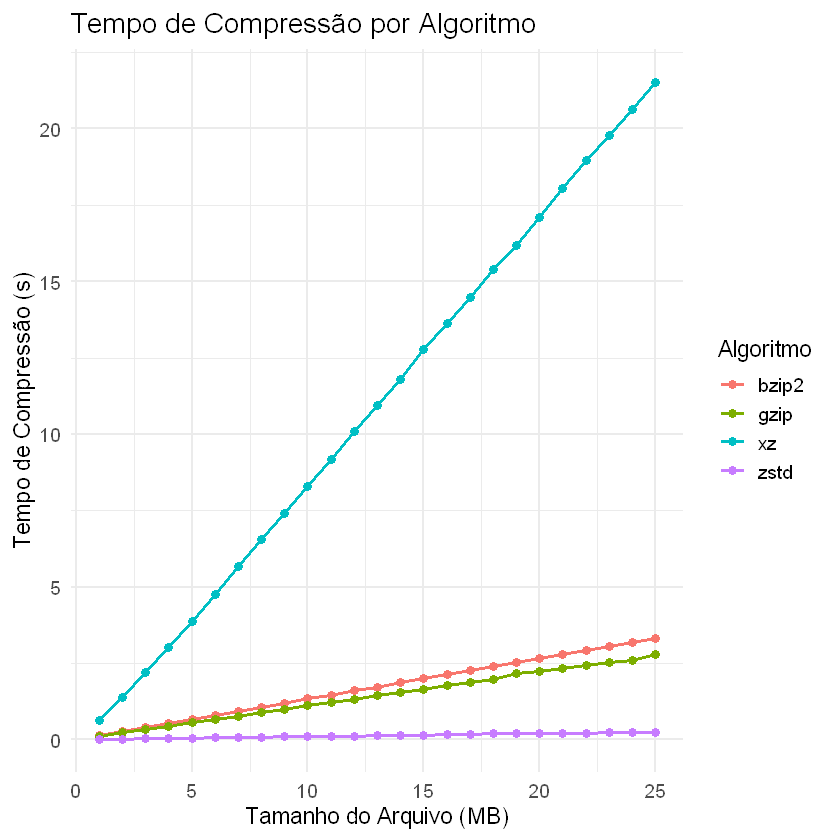

In [5]:
# -------------------------------------------------------------------
# 4) GRÁFICO 1 — TEMPO DE COMPRESSÃO
# -------------------------------------------------------------------
grafico_comp <- ggplot(resumo, aes(
  x = tamanho,
  y = media_comp,
  color = algorithm,
  group = algorithm
)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(
    title = "Tempo de Compressão por Algoritmo",
    x = "Tamanho do Arquivo (MB)",
    y = "Tempo de Compressão (s)",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_comp)

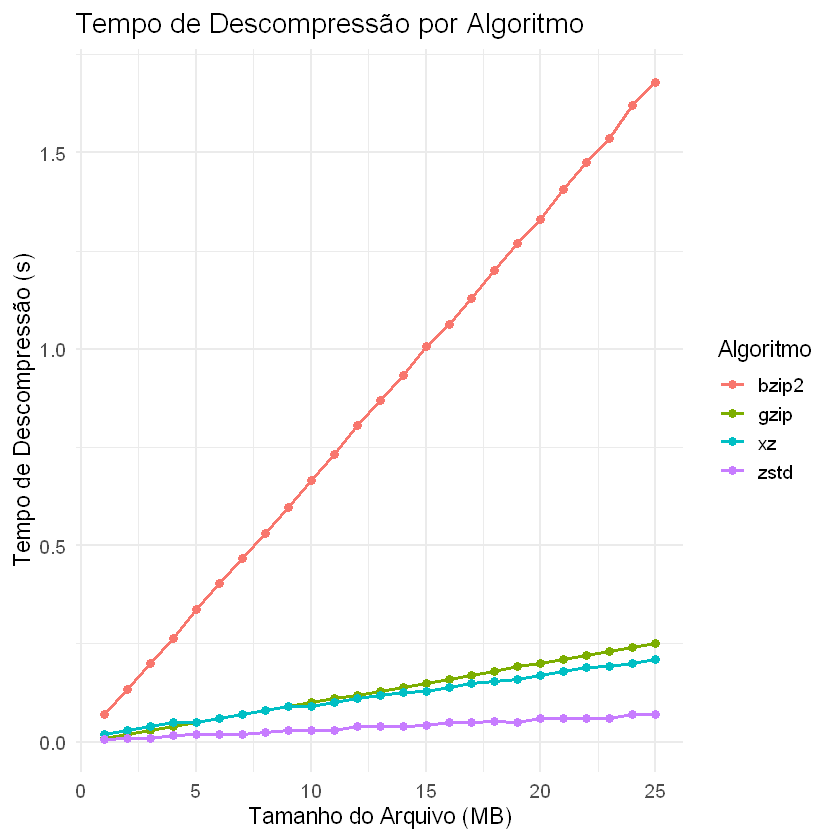

In [6]:
# -------------------------------------------------------------------
# 5) GRÁFICO 2 — TEMPO DE DESCOMPRESSÃO
# -------------------------------------------------------------------
grafico_decomp <- ggplot(resumo, aes(
  x = tamanho,
  y = media_decomp,
  color = algorithm,
  group = algorithm
)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(
    title = "Tempo de Descompressão por Algoritmo",
    x = "Tamanho do Arquivo (MB)",
    y = "Tempo de Descompressão (s)",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_decomp)

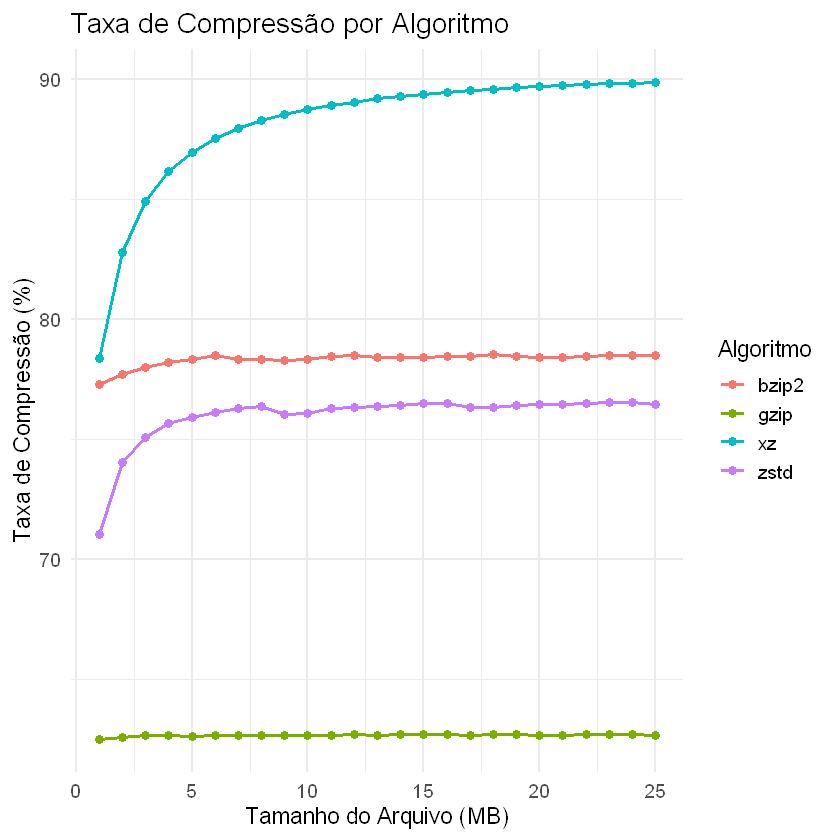

In [7]:
# -------------------------------------------------------------------
# 6) GRÁFICO 3 — TAXA DE COMPRESSÃO (PERCENTUAL)
# -------------------------------------------------------------------
grafico_rate <- ggplot(resumo, aes(
  x = tamanho,
  y = media_ratio,
  color = algorithm,
  group = algorithm
)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(
    title = "Taxa de Compressão por Algoritmo",
    x = "Tamanho do Arquivo (MB)",
    y = "Taxa de Compressão (%)",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_rate)

In [8]:
# -------------------------------------------------------------------
# 7) FUNÇÃO PARA GERAR GRÁFICOS COM REGRESSÃO
# -------------------------------------------------------------------
gera_grafico_regressao <- function(df, coluna_y, titulo, ylab){

  # criar nova sequência de valores de 25M a 35M
  newdata <- expand_grid(
    algorithm = unique(df$algorithm),
    tamanho = seq(25, 35, length.out = 80)
  )

  # ajustar modelos por algoritmo
  modelos <- df %>%
    group_by(algorithm) %>%
    group_map(~{
      lm(as.formula(paste(coluna_y, "~ tamanho")), data = .x)
    })

  # previsões
  preds <- map2_dfr(modelos, unique(df$algorithm), ~{
    tibble(
      algorithm = .y,
      tamanho = newdata$tamanho[newdata$algorithm == .y],
      pred = predict(.x, newdata[newdata$algorithm == .y, ])
    )
  })

  # gráfico final
  g <- ggplot(df, aes(x = tamanho, y = .data[[coluna_y]], color = algorithm)) +
    geom_line(size = 1) +
    geom_point(size = 2) +

    # regressão (tracejado)
    geom_line(
      data = preds,
      aes(x = tamanho, y = pred, color = algorithm),
      linetype = "dotdash",
      linewidth = 1.2,
      alpha = 0.9
    ) +

    labs(
      title = titulo,
      subtitle = "Linha tracejada = Regressão Linear (25M-35M)",
      x = "Tamanho do Arquivo (MB)",
      y = ylab,
      color = "Algoritmo"
    ) +
    theme_minimal(base_size = 14)

  return(g)
}

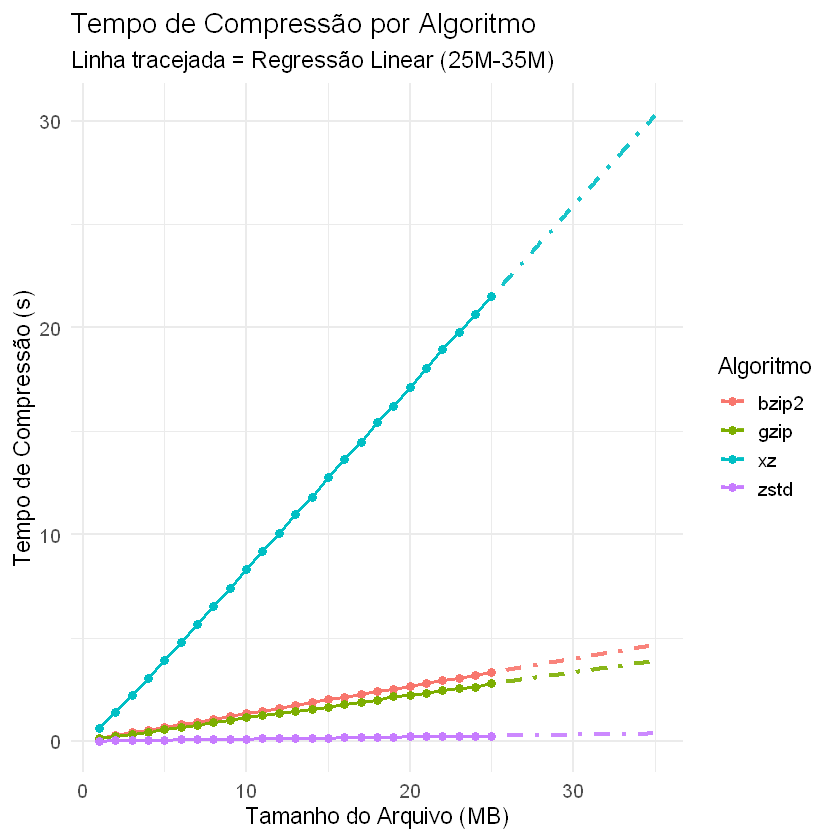

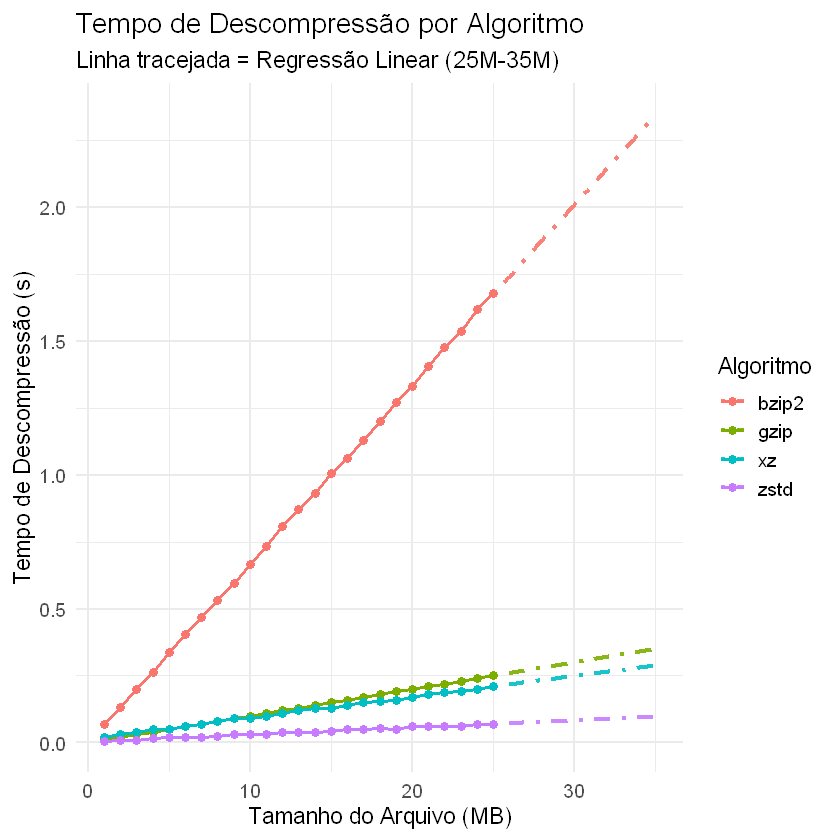

In [9]:
# -------------------------------------------------------------------
# 8) GRÁFICOS COM REGRESSÃO
# -------------------------------------------------------------------
grafico_reg_comp <- gera_grafico_regressao(
  resumo, "media_comp",
  "Tempo de Compressão por Algoritmo",
  "Tempo de Compressão (s)"
)

print(grafico_reg_comp)

grafico_reg_decomp <- gera_grafico_regressao(
  resumo, "media_decomp",
  "Tempo de Descompressão por Algoritmo",
  "Tempo de Descompressão (s)"
)

print(grafico_reg_decomp)

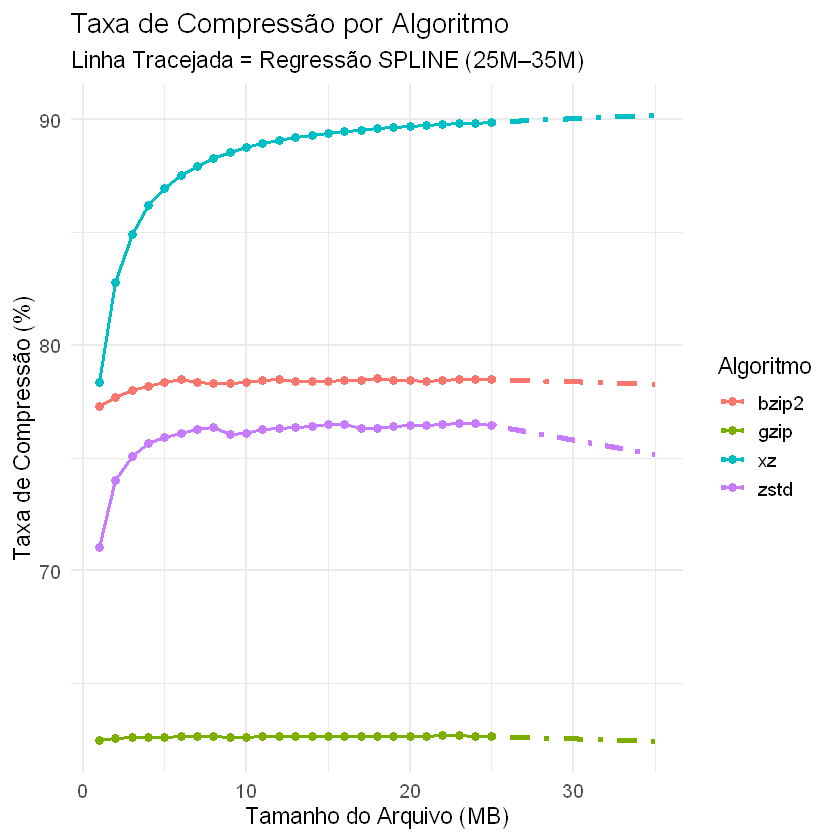

In [10]:
# -------------------------------------------------------------------
# 9) Regressão SPLINE para Taxa de Compressão
# -------------------------------------------------------------------

df <- resumo

# sequência 25–35
newdata <- expand_grid(
  algorithm = unique(df$algorithm),
  tamanho = seq(25, 35, length.out = 300)
)

# Ajustar spline para cada algoritmo
modelos <- df %>%
  group_by(algorithm) %>%
  group_split() %>%
  map(~{
    alg <- unique(.x$algorithm)
    spline_mod <- smooth.spline(.x$tamanho, .x$media_ratio)

    list(algorithm = alg, spline = spline_mod)
  })

# Gerar previsões
preds <- map_dfr(modelos, function(m) {
  dados_alg <- newdata %>% filter(algorithm == m$algorithm)

  tibble(
    algorithm = m$algorithm,
    tamanho = dados_alg$tamanho,
    pred = predict(m$spline, dados_alg$tamanho)$y
  )
})

# Gráfico final
grafico_reg_rate <- ggplot(df, aes(x = tamanho, y = media_ratio, color = algorithm)) +
  geom_point(size = 2) +
  geom_line(size = 1) +
  geom_line(
    data = preds,
    aes(x = tamanho, y = pred, color = algorithm),
    linewidth = 1.5,
    linetype = "dotdash"
  ) +
  labs(
    title = "Taxa de Compressão por Algoritmo",
    subtitle = "Linha Tracejada = Regressão SPLINE (25M–35M)",
    x = "Tamanho do Arquivo (MB)",
    y = "Taxa de Compressão (%)",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_reg_rate)


In [11]:
# -------------------------------------------------------------------
# 10) BAIXAR OS GRÁFICOS
# -------------------------------------------------------------------
ggsave("./graphs/phase3/comp_time.png", grafico_comp, width = 8, height = 5)
ggsave("./graphs/phase3/decomp_time.png", grafico_decomp, width = 8, height = 5)
ggsave("./graphs/phase3/comp_rate.png", grafico_rate, width = 8, height = 5)
ggsave("./graphs/phase3/reg_comp.png", grafico_reg_comp, width = 8, height = 5)
ggsave("./graphs/phase3/reg_decomp.png", grafico_reg_decomp, width = 8, height = 5)
ggsave("./graphs/phase3/reg_comp_rate.png", grafico_reg_rate, width = 8, height = 5)

In [12]:
# ---------------------------------------------------------
#  11) FUNÇÃO: intervalo de confiança por algoritmo e tamanho
# ---------------------------------------------------------

calcula_ic <- function(df, coluna, nivel = 0.95) {
  df %>%
    group_by(algorithm, tamanho) %>%
    summarise(
      n   = n(),
      media   = mean(.data[[coluna]]),
      sd      = sd(.data[[coluna]]),
      se      = sd / sqrt(n),                     # erro padrão
      tcrit   = qt((1 + nivel) / 2, df = n - 1),  # valor crítico t
      ic_inf  = media - tcrit * se,
      ic_sup  = media + tcrit * se,
      .groups = "drop"
    )
}


In [13]:
# TEMPO DE COMPRESSÃO (em segundos)
ic_comp <- calcula_ic(dados, "comp_time_sec")

# TEMPO DE DESCOMPRESSÃO (em segundos)
ic_decomp <- calcula_ic(dados, "decomp_time_sec")

# TAXA DE COMPRESSÃO (%)
ic_ratio <- calcula_ic(dados, "compression_ratio_pct")


In [14]:
print(ic_comp)
print(ic_decomp)
print(ic_ratio)

# A tibble: 100 × 9
   algorithm tamanho     n media      sd      se tcrit ic_inf ic_sup
   <chr>       <dbl> <int> <dbl>   <dbl>   <dbl> <dbl>  <dbl>  <dbl>
 1 bzip2           1     3 0.133 0.00577 0.00333  4.30  0.119  0.148
 2 bzip2           2     3 0.27  0       0        4.30  0.27   0.27 
 3 bzip2           3     3 0.407 0.0115  0.00667  4.30  0.378  0.435
 4 bzip2           4     3 0.543 0.0115  0.00667  4.30  0.515  0.572
 5 bzip2           5     3 0.68  0.0173  0.01000  4.30  0.637  0.723
 6 bzip2           6     3 0.807 0.00577 0.00333  4.30  0.792  0.821
 7 bzip2           7     3 0.933 0.00577 0.00333  4.30  0.919  0.948
 8 bzip2           8     3 1.07  0.00577 0.00333  4.30  1.05   1.08 
 9 bzip2           9     3 1.2   0       0        4.30  1.2    1.2  
10 bzip2          10     3 1.34  0.0321  0.0186   4.30  1.26   1.42 
# ℹ 90 more rows
# A tibble: 100 × 9
   algorithm tamanho     n media      sd      se tcrit ic_inf ic_sup
   <chr>       <dbl> <int> <dbl>   <dbl>   <db

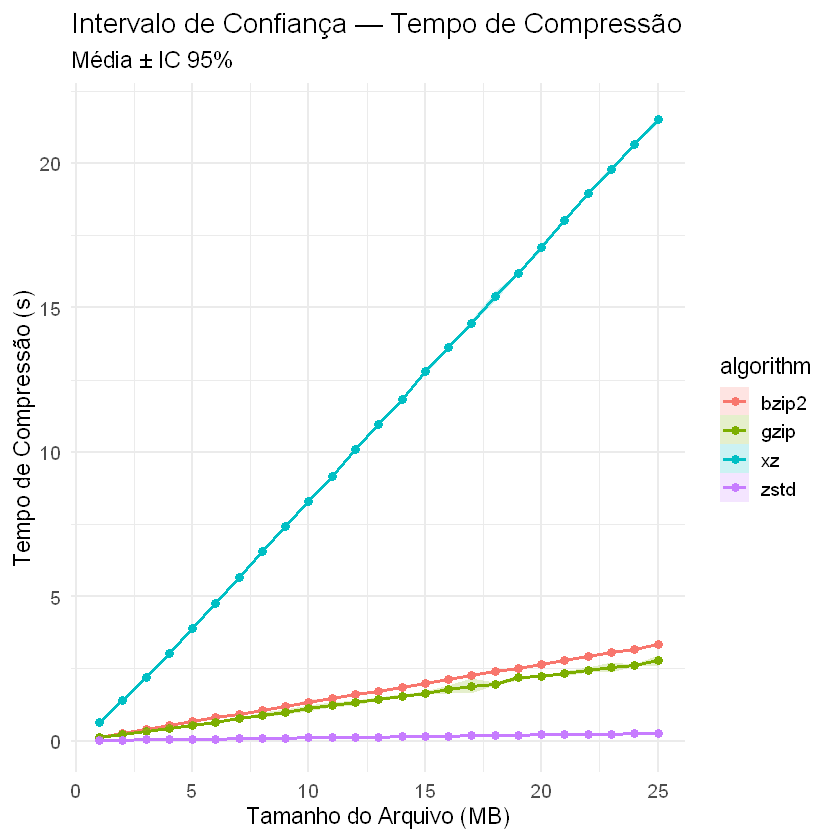

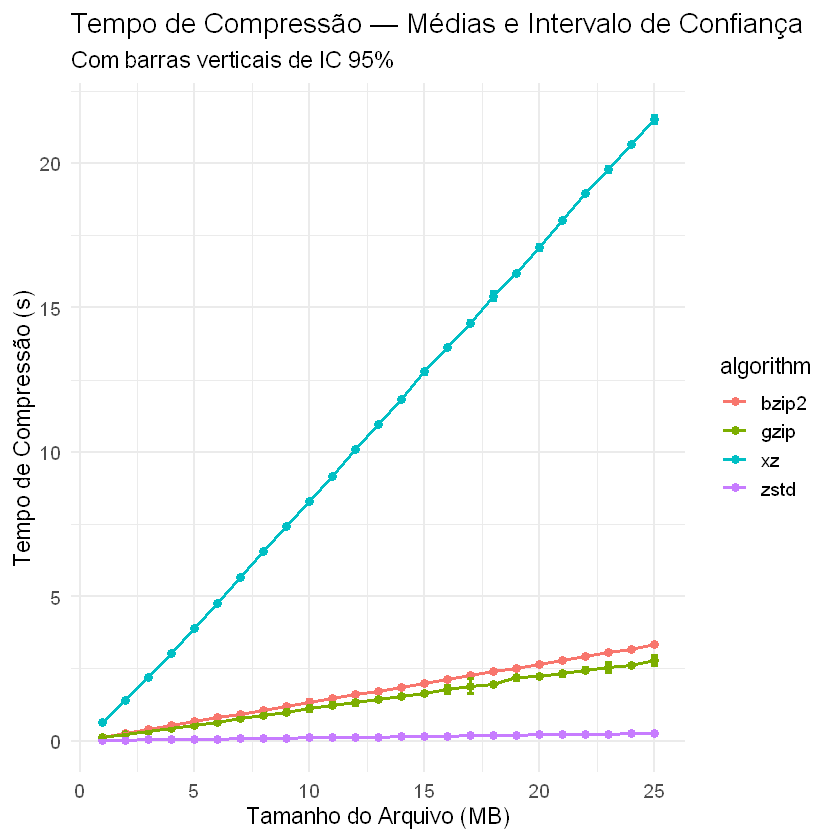

In [15]:

# -------------------------------------------------------------------
# 12) GRÁFICO COM RIBBON (MÉDIA + INTERVALO DE CONFIANÇA)
# -------------------------------------------------------------------
grafico_ic_ribbon <- ggplot(ic_comp, aes(x = tamanho, y = media, color = algorithm)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_ribbon(
    aes(ymin = ic_inf, ymax = ic_sup, fill = algorithm),
    alpha = 0.20,
    linewidth = 0,
    color = NA
  ) +
  labs(
    title = "Intervalo de Confiança — Tempo de Compressão",
    subtitle = "Média ± IC 95%",
    x = "Tamanho do Arquivo (MB)",
    y = "Tempo de Compressão (s)"
  ) +
  theme_minimal(base_size = 14)

print(grafico_ic_ribbon)

# -------------------------------------------------------------------
# 13) GRÁFICO SOMENTE MÉDIAS + IC COMO BARRA (ERRORBAR)
# -------------------------------------------------------------------
grafico_ic_errorbar <- ggplot(ic_comp, aes(x = tamanho, y = media, color = algorithm)) +
  geom_point(size = 2) +
  geom_errorbar(
    aes(ymin = ic_inf, ymax = ic_sup),
    width = 0.3,
    linewidth = 0.9
  ) +
  geom_line(linewidth = 1) +
  labs(
    title = "Tempo de Compressão — Médias e Intervalo de Confiança",
    subtitle = "Com barras verticais de IC 95%",
    x = "Tamanho do Arquivo (MB)",
    y = "Tempo de Compressão (s)"
  ) +
  theme_minimal(base_size = 14)

print(grafico_ic_errorbar)


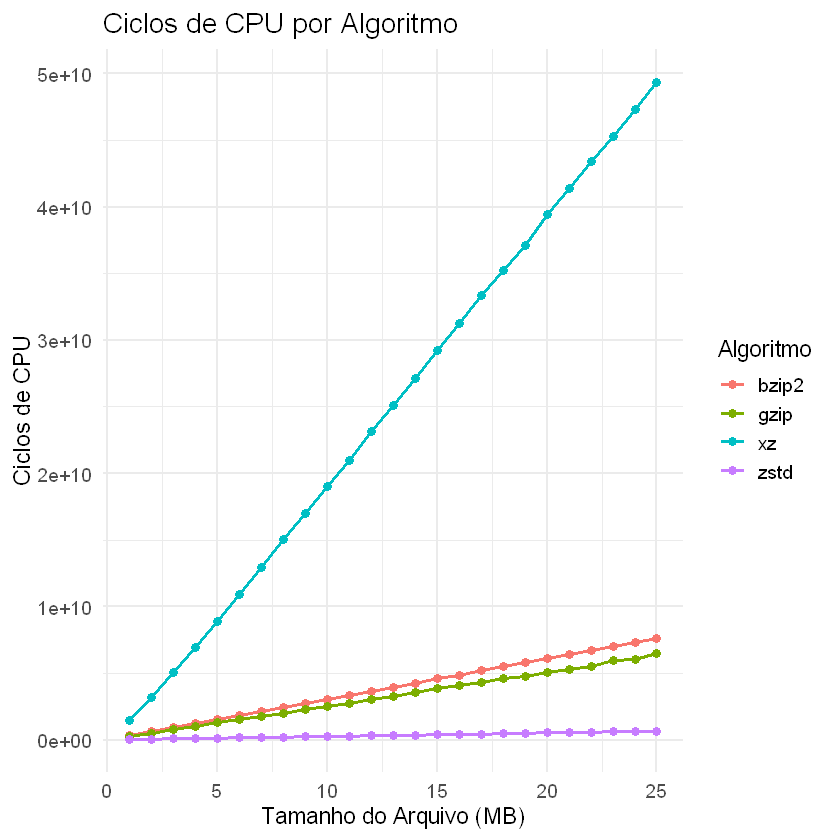

In [16]:
# -------------------------------------------------------------------
# 14) GRÁFICO — CICLOS DE CPU
# -------------------------------------------------------------------
grafico_ciclos <- ggplot(resumo, aes(
  x = tamanho,
  y = media_ciclos,
  color = algorithm,
  group = algorithm
)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(
    title = "Ciclos de CPU por Algoritmo",
    x = "Tamanho do Arquivo (MB)",
    y = "Ciclos de CPU",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_ciclos)